# 后训练技术演进

> 预训练使模型具备续写能力，但不保证它能够遵循指令、回答问题或按指定格式推理。后训练通常保持模型结构，调整不同上下文中的输出概率。
>
> SFT 学习外部示范，RL 根据行为的奖励更新策略，OPD（On-Policy Distillation，同策略蒸馏）让学生生成轨迹，再由 Teacher 提供逐 Token 监督。
>
> 本章介绍四组内容：
>
> 1. **范式演进**：SFT 的外部示范、RL 的奖励更新、OPD 在学生前缀上的反馈。
> 2. **数学基础**：Exposure Bias 与学生前缀，Forward KL 与 Reverse KL 两种目标。
> 3. **反馈与估计器**：自蒸馏、sampled-token / top-k / full-vocab 信号，以及采样 KL 估计器。
> 4. **流程与落地**：rollout、Teacher 打分、学生更新及适用条件。NumPy 示例演示分布和打分，不是完整神经网络训练器。


## 1. 后训练的范式演进

怎么理解 SFT、RL、OPD 的联系与区别？我们先从最基础的视角看起。语言模型本质上是一个概率分布生成器——给定上下文，给词表里每个 token 一个概率。

那么，后训练是做什么的呢？它做的事，就是把这个分布重新塑形。也就是说，提高某些行为的概率，压低另一些。

### 1.1 模型输出分布

要理解 SFT、RL、OPD 的联系和区别，为什么要从基础概念开始？因为必须先看清模型原本的输出形态。也就是说，**语言模型本质上是一个概率分布生成器**。

给定一段上下文，模型会对词表中的每个 token 分配一个概率——这就是模型在这个上下文下的输出分布。换句话说，分布描述了模型此刻对每个词的选择倾向。

后训练做的事情，就是把这个概率分布重新塑形。它提高某些行为的概率，降低另一些行为的概率。

先建立这个直观理解，我们再看三种方法各自怎么做。

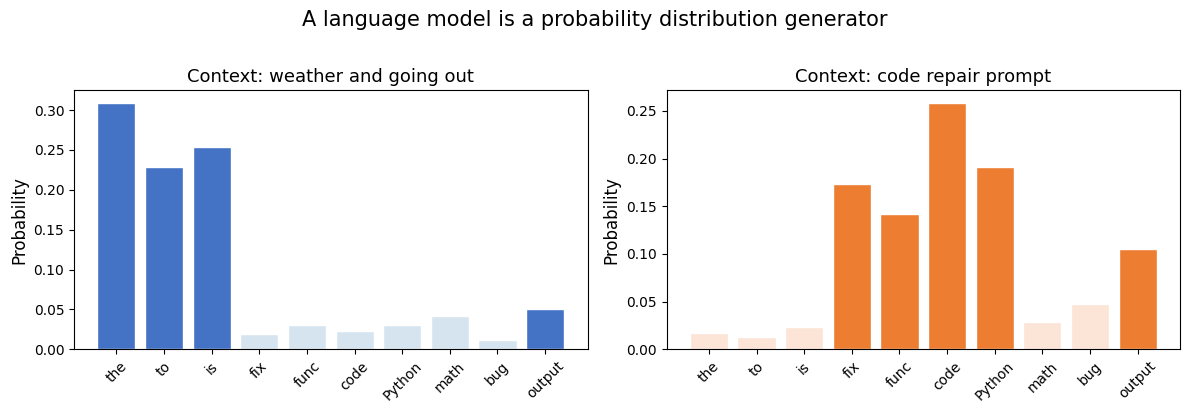

→ 同一个模型，不同上下文 → 输出概率分布会明显不同
→ 后训练就是：在特定上下文里，把分布重塑成我们想要的样子


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

def softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    e = np.exp(logits - logits.max())
    return e / e.sum()

# 小词表
vocab = ["the", "to", "is", "fix", "func", "code", "Python", "math", "bug", "output"]
vocab_size = len(vocab)

# 同一个模型，两个不同上下文的 logits
logits_chat = np.array([0.8, 0.5, 0.6, -2.0, -1.5, -1.8, -1.5, -1.2, -2.5, -1.0])
logits_code = np.array([-1.5, -1.8, -1.2, 0.8, 0.6, 1.2, 0.9, -1.0, -0.5, 0.3])

probs_chat = softmax(logits_chat)
probs_code = softmax(logits_code)

# 可视化：同一模型、不同上下文 → 完全不同分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors_chat = ['#4472C4' if p > 0.05 else '#D6E4F0' for p in probs_chat]
ax1.bar(vocab, probs_chat, color=colors_chat, edgecolor='white')
ax1.set_title("Context: weather and going out", fontsize=13)
ax1.set_ylabel("Probability", fontsize=12)
ax1.tick_params(axis='x', rotation=45)

colors_code = ['#ED7D31' if p > 0.05 else '#FCE4D6' for p in probs_code]
ax2.bar(vocab, probs_code, color=colors_code, edgecolor='white')
ax2.set_title("Context: code repair prompt", fontsize=13)
ax2.set_ylabel("Probability", fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("A language model is a probability distribution generator", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"→ 同一个模型，不同上下文 → 输出概率分布会明显不同")
print(f"→ 后训练就是：在特定上下文里，把分布重塑成我们想要的样子")

### 1.2 SFT 与外部数据分布

为什么先从 SFT 说起？因为 SFT（Supervised Fine-Tuning）是最直观的后训练方法。具体怎么做呢？先准备一个标注数据集，训练时模型看到 prompt 和标准答案，通过 Cross-Entropy 学习。

学习的目标很明确：在标准答案 token 出现的位置，提高模型生成它的概率。换句话说，模型被要求模仿数据集里的标准回答。

从分布角度看，SFT 的目标分布来自外部数据集。它强在直接——尤其适合冷启动，当模型还不会遵循指令时，SFT 能迅速建立基本行为模板。

但是 SFT 的风险也来自这里。标准答案里的每个 token 都会被当作学习目标——关键推理 token 要学，数据集里的风格词也要学，偶然表达和模板口癖也会被学进去。

为什么这是风险？因为 SFT loss 本身不知道这些差别，只会把整条答案都往上推。也就是说，模型分不清重点，一律照搬。

下面用归一化软目标直观展示 CE 梯度；普通标注 SFT 每个位置通常使用 one-hot 目标。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === SFT：模拟 CE 梯度下降，把模型分布拉向外部目标分布 ===
print("=== SFT：向外部数据分布模仿 ===\n")

# 预训练模型在某个代码修复上下文的输出分布（偏向通用高频词）
init_logits = np.array([1.8, 1.5, 1.6, -1.0, -0.8, -0.5, -0.5, -0.3, -0.8, -0.5])
init_model = softmax(init_logits)

# 外部标注数据给出的目标分布（任务相关 token 概率更高）
target = np.array([0.02, 0.01, 0.02, 0.25, 0.20, 0.15, 0.20, 0.10, 0.03, 0.02])
target = target / target.sum()  # normalize the illustrative soft target

# 模拟 CE 梯度下降：dCE/dlogits = softmax(logits) - target
model_logits = init_logits.copy()
lr = 0.3
steps = 12
history = [softmax(model_logits)]

for step in range(steps):
    model_probs = softmax(model_logits)
    grad = model_probs - target          # CE 对 logits 的梯度
    model_logits = model_logits - lr * grad  # 梯度下降
    history.append(softmax(model_logits))

final_model = history[-1]

# 可视化：SFT 前 vs 目标分布 vs SFT 后
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(vocab, init_model, color='#4472C4', edgecolor='white')
axes[0].set_title('Before SFT (pretrained model)', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(init_model):
    if v > 0.05:
        axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

axes[1].bar(vocab, target, color='#ED7D31', edgecolor='white')
axes[1].set_title('Target distribution from external dataset', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(target):
    if v > 0.05:
        axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

axes[2].bar(vocab, final_model, color='#70AD47', edgecolor='white')
axes[2].set_title(f'After SFT ({steps} gradient steps)', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(final_model):
    if v > 0.05:
        axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('SFT: cross-entropy pulls the model\ntoward the target', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 打印关键变化
ce_init = -np.sum(target * np.log(init_model + 1e-10))
ce_final = -np.sum(target * np.log(final_model + 1e-10))
print(f"CE Loss: {ce_init:.4f} → {ce_final:.4f}")
print(f"\n关键观察：")
print(f"  'fix' 概率: {init_model[3]:.3f} → {final_model[3]:.3f} (目标={target[3]:.3f}) ↑")
print(f"  'code' 概率: {init_model[5]:.3f} → {final_model[5]:.3f} (目标={target[5]:.3f}) ↑")
print(f"  'the' 概率:   {init_model[0]:.3f} → {final_model[0]:.3f} (目标={target[0]:.3f}) ↓")
print(f"\n→ SFT 把整个分布拉向外部数据——任务 token 概率上升，通用高频词被压低")
print(f"→ 风险：外部数据里的所有 token（包括风格词、偶然表达）都会被同等对待")
print(f"→ 如果外部分布离原模型很远，旧能力可能被覆盖（灾难性遗忘）")

### 1.3 RL 与价值筛选

这里考虑 on-policy RL：模型按当前策略生成回答，reward function 打分，再提高高奖励行为相对于低奖励行为的概率。

样本来自当前策略，并不保证更新幅度小或不会遗忘；奖励质量、更新步长和正则约束都很重要。结果级奖励往往稀疏：知道答案错了，不一定能找到最早出错的一步。RL 也可以使用更密集的反馈。

下面为每个 Token 设置示意奖励，用 REINFORCE 更新。虽然动作来自采样，Softmax 梯度会改变所有 logits，并非只更新采样到的 Token。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === RL：模拟 REINFORCE 策略梯度，从自身样本中筛选高 reward 行为 ===
print("=== RL：在模型自己生成的行为里筛选高 reward 方向 ===\n")

np.random.seed(42)

# 初始模型分布（对代码修复上下文）
init_logits = np.array([-1.0, -1.2, -0.8, 0.8, 0.6, 1.2, 0.5, -0.5, -0.3, 0.1])
init_probs = softmax(init_logits)

# 每个 token 的真实任务价值：代码是否正确、测试是否通过
true_reward = np.array([0, 0, 0, 8, 6, 7, 5, 3, 4, 2])  # 对应 vocab 顺序

# 模拟 REINFORCE: d(-log π(a) * R) / dlogits = -R * (one_hot(a) - π)
current_logits = init_logits.copy()
lr = 0.08
n_rounds = 8
n_samples = 20

history = [softmax(current_logits)]

for round_idx in range(n_rounds):
    probs = softmax(current_logits)
    gradient = np.zeros(vocab_size)
    
    for _ in range(n_samples):
        a = np.random.choice(vocab_size, p=probs)
        r = true_reward[a]
        # REINFORCE 梯度（负 reward 方向，因为要最小化负 reward）
        one_hot = np.zeros(vocab_size)
        one_hot[a] = 1
        gradient += -r * (one_hot - probs)
    
    gradient /= n_samples
    current_logits = current_logits - lr * gradient
    history.append(softmax(current_logits))

final_probs = history[-1]

# 可视化：RL 前 vs RL 后，按 reward 上色
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

reward_norm = (true_reward - true_reward.min()) / (true_reward.max() - true_reward.min() + 1e-10)
colors = [plt.cm.RdYlGn(0.2 + 0.6 * rn) for rn in reward_norm]

ax1.bar(vocab, init_probs, color=colors, edgecolor='white')
ax1.set_title('Before RL (initial policy distribution)', fontsize=13)
ax1.set_ylabel('Probability', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(init_probs):
    if v > 0.05:
        ax1.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax2.bar(vocab, final_probs, color=colors, edgecolor='white')
ax2.set_title(f'After RL ({n_rounds} rounds x {n_samples} samples/round)', fontsize=13)
ax2.set_ylabel('Probability', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(final_probs):
    if v > 0.05:
        ax2.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('RL: policy gradient increases\nhigh-reward token probability', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("概率变化（按 reward 高低排列，绿=高价值，红=低价值）：")
for i in np.argsort(true_reward)[::-1]:
    change = final_probs[i] - init_probs[i]
    direction = "↑" if change > 0.005 else ("↓" if change < -0.005 else "→")
    print(f"  {vocab[i]:6s} (reward={true_reward[i]}): "
          f"{init_probs[i]:.3f} → {final_probs[i]:.3f} ({change:+.3f}) {direction}")

print(f"\n→ on-policy：样本来自模型自己当前会生成的分布")
print("→ Softmax 梯度改变全部 logits；on-policy 不保证小幅更新或避免遗忘")
print(f"→ 高 reward token 概率逐步上升，低 reward token 被压制")
print(f"→ 但 reward 是结果级的（稀疏），模型不知道「哪一步」导致了好/坏结果")

### 1.4 同策略蒸馏 OPD

OPD 将 Teacher 监督与 Student 自生成轨迹结合：学生先写回答，老师在学生实际写出的每个前缀上给出下一 Token 分布，学生再学习反馈。

离线蒸馏通常使用数据集或老师提供的固定轨迹；OPD 则沿着学生自己的路径查询老师，包括偏离参考答案的前缀。

下面用扰动 logits 模拟三个位置，并固定 Teacher 分布，再在一个固定上下文上优化 Reverse KL。这是目标与梯度的演示，不是训练好的自回归模型，也不是完整 OPD 循环。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === OPD：student 自己 rollout，teacher 在 student 的 prefix 上给 token 级纠偏 ===
print("=== OPD：学生自己走，老师在学生走到的位置给密集指导 ===\n")

np.random.seed(42)

# Student 模型——初始能力较弱，分布较分散
student_base_logits = np.array([0.7, 0.2, 0.3, -0.5, -0.3, -0.1, -0.2, -0.4, -0.6, -0.4])
# Teacher 模型——能力更强，分布更确定（温度更低）
teacher_base_logits = np.array([-0.5, -0.8, -0.4, 1.2, 0.8, 1.5, 0.9, -0.5, -0.3, 0.3])

s_probs = softmax(student_base_logits)
t_probs = softmax(teacher_base_logits / 0.6)  # teacher 温度更低 → 分布更尖锐

# 1. Student 自回归生成 3 步（模拟不同 prefix 下分布略有变化）
print("1. Student 自回归生成 3 步：")
seq = []
positions_logits = []
for step in range(3):
    # 每一步的 logits 在当前基础上略有偏移（模拟 prefix 变化）
    step_logits = student_base_logits + np.random.RandomState(step * 7).randn(vocab_size) * 0.4
    positions_logits.append(step_logits)
    step_probs = softmax(step_logits)
    tok_id = np.random.choice(vocab_size, p=step_probs)
    seq.append(tok_id)
    print(f"   Step {step+1}: 选了 '{vocab[tok_id]}' (最看好 '{vocab[np.argmax(step_probs)]}')")

# 2. Teacher 在每个 student prefix 上给逐 token 分布
print(f"\n2. Teacher 在每个 student prefix 上提供完整 token 分布：")
total_kl = 0
for t in range(3):
    s_p = softmax(positions_logits[t])
    t_p = softmax(teacher_base_logits / 0.6)
    kl = np.sum(s_p * (np.log(s_p + 1e-10) - np.log(t_p + 1e-10)))
    total_kl += kl
    print(f"   位置 {t}: 学生选了 '{vocab[seq[t]]}'，"
          f"老师最看好 '{vocab[np.argmax(t_p)]}'，"
          f"KL(s||t) = {kl:.4f}")

# 3. 模拟 OPD 梯度更新：最小化 KL(student || teacher)
# dKL(s||t)/ds_logits = s_probs - t_probs（当 t 固定时）
# 这是 OPD 的关键：把 student 分布拉向 teacher，但只在 student 当前概率高的位置
s_logits = student_base_logits.copy()
lr = 0.15
opd_steps = 10
opd_history = [softmax(s_logits)]

for step in range(opd_steps):
    s_p = softmax(s_logits)
    log_ratio = np.log(s_p) - np.log(t_probs)
    grad = s_p * (log_ratio - np.sum(s_p * log_ratio))
    s_logits = s_logits - lr * grad  # 梯度下降
    opd_history.append(softmax(s_logits))

s_final = opd_history[-1]

# 可视化：Student 前 vs Teacher vs Student 后
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(vocab, softmax(student_base_logits), color='#4472C4', edgecolor='white')
axes[0].set_title('Before OPD (initial student distribution)', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(vocab, t_probs, color='#ED7D31', edgecolor='white')
axes[1].set_title('Teacher distribution (target)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(vocab, s_final, color='#70AD47', edgecolor='white')
axes[2].set_title(f'After OPD ({opd_steps} KL minimization steps)', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('OPD: KL minimization moves the student toward the teacher'
             'at a fixed context (toy gradient example)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n  总 KL loss = {total_kl:.4f}")
print(f"\n→ OPD 的特征：")
print(f"  on-policy：prefix 来自 student 自己生成 → 训练分布在模型真实访问的区域")
print(f"  dense signal：每个 token 位置都有 teacher 分布指导 → 不像 RL 只给结果 reward")
print("  Reverse KL 用学生概率加权 log-ratio 梯度，不保证保留原有能力")
print("  固定 logits 演示目标，不是模型质量或遗忘的实测结果")


### 1.5 三种范式的对比

把 SFT、RL、OPD 放在一起看，核心区别在哪里？不在于「有没有 teacher」或「有没有 reward」，而在于数据来源和信号密度。下面的表格从分布视角总结三者的关键差异。

只看两个问题就能分清所有方法：

1. **训练时的前缀（prefix）是谁写的？**
2. **学习目标（target）是谁给的？**

| 方法 | prefix 来源 | target 来源 | 类比 |
|:---|:---|:---|:---|
| **SFT** | 数据集标准答案 | 数据集标准答案 | 背课本 |
| **离线蒸馏** | Teacher 写好的固定前缀 | Teacher 的概率分布 | 背老师写的范文 |
| **OPD** | **Student 自己生成的前缀** | Teacher 在这个学生前缀上的分布 | 学生自己写，老师批改 |
| **OPSD** | **Student 自己生成的前缀** | 同一个模型的开卷版本 | 学生闭卷做题，开卷的自己来教 |

核心区别就是 prefix 那一列。也就是说，OPD 和 OPSD 的 prefix 是学生自己写的，其他都是别人写好的。

下图是手工构造的示意分布，不是三个目标优化后的结果；局部掩码不能证明真实训练的漂移边界。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === 三者核心区别：可视化对比 ===
print("=== 一张表：SFT vs RL vs OPD（从分布视角） ===\n")

header = f"{'':22} {'SFT':^18} {'RL':^18} {'OPD':^18}"
print(header)
print("-" * 76)

rows = [
    ("训练数据来源", "外部标注数据集", "student 自己生成", "student 自己生成"),
    ("是否 on-policy", "否", "是", "是"),
    ("监督信号密度", "逐 token（密集）", "结果级（稀疏）", "逐 token（密集）"),
    ("目标来源", "标注答案分布", "reward 定义的高价值", "teacher 的 token 分布"),
    ("分布移动方式", "整体拉向外部分布", "在当前分布中筛选", "在当前分布中局部纠偏"),
    ("优势", "冷启动、格式塑造", "可验证任务", "on-policy + dense"),
    ("风险", "过度牵引、遗忘", "reward 稀疏、成本高", "teacher 信号可能有偏"),
]

for r in rows:
    print(f"{r[0]:22} {r[1]:^18} {r[2]:^18} {r[3]:^18}")

print(f"\n→ 三者不是替代关系，而是三种不同的「分布移动方式」")

# 可视化：用一个示意性的「分布热力图」来对比三种方法
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 构造一个 2D 示意分布网格（模拟 token 空间）
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# 原始模型分布（中心偏左上的高斯）
mu_orig = np.array([-0.8, 0.5])
sigma = np.array([[1.2, -0.3], [-0.3, 1.5]])
Z_orig = np.exp(-0.5 * ((X - mu_orig[0])**2 / sigma[0,0] 
                         + (Y - mu_orig[1])**2 / sigma[1,1]
                         - 2 * (X - mu_orig[0]) * (Y - mu_orig[1])
                         * sigma[0,1] / (sigma[0,0]*sigma[1,1])))

# —— SFT：整体拉向外部目标（右上） ——
mu_target = np.array([1.2, 0.3])
Z_target = np.exp(-0.5 * ((X - mu_target[0])**2 / 0.8 + (Y - mu_target[1])**2 / 0.8))
Z_sft = 0.3 * Z_orig + 0.7 * Z_target  # SFT 后：整体向目标偏移

ax = axes[0]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_sft, levels=8, cmap='Oranges', alpha=0.5)
ax.arrow(mu_orig[0], mu_orig[1], mu_target[0]-mu_orig[0], mu_target[1]-mu_orig[1],
         head_width=0.25, head_length=0.2, fc='red', ec='red', linewidth=2)
ax.set_title('SFT: pull toward external distribution', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# —— RL：在原分布中筛选高 reward 子区域 ——
Z_rl = Z_orig.copy()
# 在 reward 高的区域（右上）增强信号
reward_mask = (X > 0) & (Y > -1) & (Y < 1.5)
Z_rl[reward_mask] *= 2.0
Z_rl[~reward_mask] *= 0.5
Z_rl = Z_rl / Z_rl.sum()

ax = axes[1]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_rl, levels=8, cmap='Greens', alpha=0.5)
ax.set_title('RL: select high-reward directions\ninside its own distribution', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# —— OPD：在自身分布的高概率区局部纠偏 ——
Z_opd = Z_orig.copy()
# 在模型自身高概率区（中心附近）向 target 方向微调
local_mask = (Z_orig > Z_orig.max() * 0.3)
shift = Z_target * 0.3
Z_opd[local_mask] = Z_orig[local_mask] * 0.7 + shift[local_mask]
Z_opd = Z_opd / Z_opd.sum()

ax = axes[2]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_opd, levels=8, cmap='Purples', alpha=0.5)
ax.set_title('OPD: teacher corrects each token\non student trajectories', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Schematic distributions for three post-training methods\n'
             '(blue=original distribution, orange/green/purple=updated distribution)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print(f"\n→ SFT：外部答案告诉模型「答案应该长这样」")
print(f"→ RL：环境告诉模型「你自己的哪些行为更有价值」")
print(f"→ OPD：老师告诉模型「你自己走到这里时，下一步应该怎么走」")

In [ ]:
import numpy as np

np.random.seed(42)

# 模拟词汇表
vocab = {"我": 0, "昨天": 1, "去了": 2, "学校": 3, "公园": 4, "超市": 5, "很": 6, "开心": 7, "无聊": 8, "累": 9}
id2token = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)

def softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    exp_logits = np.exp(logits - logits.max())
    return exp_logits / exp_logits.sum()

def log_softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    m = logits.max()
    return logits - m - np.log(np.exp(logits - m).sum())

# 模拟学生模型：根据输入序列输出 logits
def student_model(input_ids):
    rng = np.random.RandomState(sum(input_ids) * 7 + 42)
    return rng.randn(vocab_size) * 2

# 模拟老师函数：不同种子和尺度，不代表真实能力
def teacher_model(input_ids):
    rng = np.random.RandomState(sum(input_ids) * 13 + 7)
    return rng.randn(vocab_size) * 1.2

print("词汇表和模型模拟函数准备完毕！")

OPD 有两个要分开看的特征：前缀来自学生，反馈可以细到每个 Token。下一节用 Exposure Bias 解释前一个特征。后续模拟函数返回确定性的伪随机 logits，它们的熵不能证明真实模型能力。


## 2. Exposure Bias

这是理解 OPD 动机的关键概念之一。换句话说，要想明白为什么 OPD 强调在自己的轨迹上训练，必须先掌握 Exposure Bias。

```
训练时（SFT / 离线蒸馏）:
  前缀永远是标准答案的前半段
  比如: "我昨天去了" → 学预测 "学校"
  学生看到的前缀都是语法正确、语义通顺的

推理时（学生自己生成）:
  学生可能写出离谱的前缀
  比如: "我昨天很公园" → 现在要预测下一个词？
  学生从没见过 "我昨天很公园" 这种前缀！
  → 可能变得不稳定或继续偏离
```

**这就是 Exposure Bias**：训练时站在「正确轨道」上，推理时一旦走偏就进入未知领域。换句话说，模型在训练阶段只接触正确前缀，而推理时若生成错误前缀便缺乏应对经验，因此容易不稳定。

Exposure Bias 指答案前缀的错位，不等于用户 prompt 的分布变化。


In [ ]:
import numpy as np

# 直观演示 Exposure Bias：用伪随机 logits 演示参考前缀与生成前缀
print("=== Exposure Bias 演示 ===")
print()

# 训练时的前缀：标准答案的前半段
train_prefix = [0, 1, 2]  # "我昨天去了"
print(f"训练时的前缀: {[id2token[i] for i in train_prefix]} ← 数据集给的，语法正确")
t_logits = teacher_model(train_prefix)
t_probs = softmax(t_logits)
top3 = np.argsort(t_probs)[-3:][::-1]
print("  学生在这个前缀下被训练，老师最看好的 3 个词:")
for idx in top3:
    print(f"    '{id2token[idx]}': {t_probs[idx]:.3f}")
print()

# 推理时：学生自己生成，可能走偏
print("推理时，学生自回归生成:")
np.random.seed(99)
student_sequence = [0]  # "我"
for step in range(3):
    s_logits = student_model(student_sequence)
    s_probs = softmax(s_logits)
    next_token = np.random.choice(vocab_size, p=s_probs)
    student_sequence.append(next_token)
    print(f"  Step {step+1}: 输入 {[id2token[i] for i in student_sequence[:-1]]} "
          f"→ 采样到 '{id2token[next_token]}' (概率={s_probs[next_token]:.3f})")
print()

# 检查学生生成的离谱前缀下模型的困惑程度
weird_prefix = student_sequence[:-1]
s_logits_weird = student_model(weird_prefix)
s_probs_weird = softmax(s_logits_weird)
entropy = -np.sum(s_probs_weird * np.log(s_probs_weird + 1e-10))
print(f"学生生成的前缀: {[id2token[i] for i in weird_prefix]}")
print(f"  模型输出熵: {entropy:.3f} (越高越不确定)")
print(f"  最高概率的词: '{id2token[np.argmax(s_probs_weird)]}' ({np.max(s_probs_weird):.3f})")
print()
print("→ 此处没有真实训练历史；随机 logits 的熵只描述模拟分布。")
print("→ Exposure Bias：训练和推理的 prefix 分布不一致。")

## 3. OPD 的机制

OPD 的核心就三步。具体流程如下面的代码所示。

```
Step 1: Student 自己生成一段回答（rollout）
  Prompt: "我昨天" → Student 生成: "我昨天去了公园很开心"

Step 2: Teacher 在 Student 的每个 prefix 上给反馈
  位置 2: prefix=[我, 昨天], Student 写了"去了" → Teacher: "还行"
  位置 3: prefix=[我, 昨天, 去了], Student 写了"公园" → Teacher: "可以"
  位置 4: prefix=[我, 昨天, 去了, 公园], Student 写了"很" → Teacher: "不太对"

Step 3: 根据 Teacher 的反馈更新 Student
  Teacher 认可的词 → 提高概率
  Teacher 不认可的词 → 降低概率
```

关键：Student 是在**自己真实写出来的轨迹**上被纠正的。换句话说，即使写出了「我昨天很公园」这种离谱前缀，Teacher 也会在这个离谱前缀上告诉它下一步该怎么走。因此，推理时遇到同样的离谱前缀，Student 就知道怎么办了。

这提供学生会遇到的位置上的反馈，不保证从所有错误前缀恢复。下面仅打印打分，不更新参数；温度为 1，因此采样策略与学生 log-probability 一致。


In [8]:
import numpy as np

# 演示 OPD 的核心：Student 自己 rollout，Teacher 在 Student 的 prefix 上打分
print("=== OPD 核心流程演示 ===")
print()

prompt = [0, 1]  # "我昨天"
sequence = prompt.copy()
temperature = 1.0

print(f"Prompt: {[id2token[i] for i in prompt]}")
print()

# Step 1: Student rollout（学生自己写）
print("Step 1: Student 自回归生成")
for step in range(3):
    logits = student_model(sequence)
    probs = softmax(logits / temperature)
    next_token = np.random.choice(vocab_size, p=probs)
    sequence.append(next_token)
    print(f"  前缀={[id2token[i] for i in sequence[:-1]]} → 采样 {id2token[next_token]}")

print(f"\n生成序列: {[id2token[i] for i in sequence]}")
print()

# Step 2: Teacher 在每个位置打分
print("Step 2: Teacher 在 Student 自己的 prefix 上评估")
for t in range(len(prompt), len(sequence)):
    prefix = sequence[:t]
    sampled_token = sequence[t]
    
    s_logits = student_model(prefix)
    t_logits = teacher_model(prefix)
    s_logp = log_softmax(s_logits)[sampled_token]
    t_logp = log_softmax(t_logits)[sampled_token]
    
    advantage = t_logp - s_logp
    
    print(f"  位置 {t}: prefix={[id2token[i] for i in prefix]}")
    print(f"    Student 写了 '{id2token[sampled_token]}', 学生logp={s_logp:.3f}, 老师logp={t_logp:.3f}")
    print(f"    advantage = {advantage:+.3f} → {'✅ 加分' if advantage > 0 else '❌ 扣分'}")

print()
print("关键：不管 Student 写的是什么离谱内容，Teacher 都在这个真实的 prefix 上给反馈！")

=== OPD 核心流程演示 ===

Prompt: ['我', '昨天']

Step 1: Student 自回归生成
  前缀=['我', '昨天'] → 采样 去了
  前缀=['我', '昨天', '去了'] → 采样 很
  前缀=['我', '昨天', '去了', '很'] → 采样 公园

生成序列: ['我', '昨天', '去了', '很', '公园']

Step 2: Teacher 在 Student 自己的 prefix 上评估
  位置 2: prefix=['我', '昨天']
    Student 写了 '去了', 学生logp=-3.118, 老师logp=-2.268
    advantage = +0.850 → ✅ 加分
  位置 3: prefix=['我', '昨天', '去了']
    Student 写了 '很', 学生logp=-2.144, 老师logp=-2.923
    advantage = -0.779 → ❌ 扣分
  位置 4: prefix=['我', '昨天', '去了', '很']
    Student 写了 '公园', 学生logp=-0.636, 老师logp=-5.154
    advantage = -4.518 → ❌ 扣分

关键：不管 Student 写的是什么离谱内容，Teacher 都在这个真实的 prefix 上给反馈！


## 4. Forward KL 与 Reverse KL

KL 散度不对称，也不是距离度量：

$$D_{KL}(P\|Q)\ne D_{KL}(Q\|P).$$

固定 Teacher、训练 Student 时，可选择两种目标：

$$\text{Forward KL: }D_{KL}(P_T\|P_S),\qquad \text{Reverse KL: }D_{KL}(P_S\|P_T).$$

Forward KL 在 Teacher 分布下取期望。学生容量受限时，常倾向覆盖老师的多个模式。Reverse KL 在 Student 分布下取期望，可能集中于某个老师认可的模式。这是受限分布族下的直觉，不保证答案必然平均化，也不保证某个方向质量更好。

轨迹来源与 KL 方向是两个选择：OPD 可以在学生前缀上使用 Forward KL、Reverse KL 或广义散度；离线数据也不等于 Forward KL。在固定上下文、无约束的类别分布下，两者都在学生完全匹配老师时取得最小值。

下面的两组风格概率是手工指定的，不是优化后的解。不同方向、不同分布对的 KL 数值不能用来判断哪种训练方法更好。


In [ ]:
import numpy as np

# 用真实概率分布演示 Forward KL vs Reverse KL
print("=== Forward KL vs Reverse KL 直觉 ===")
print()

# 模拟 Teacher 的三种风格概率分布
teacher_probs = np.array([0.40, 0.35, 0.25])
styles = ["学术严谨风", "幽默风趣风", "简洁直接风"]

print("Teacher 认为好答案有三种风格:")
for i, (style, prob) in enumerate(zip(styles, teacher_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print()

# 手工候选分布的 Forward KL: Student 被要求覆盖所有模式
# 用一个"平均化"的 Student 分布来展示
student_avg_probs = np.array([0.33, 0.33, 0.34])  # 均匀化
forward_kl = np.sum(teacher_probs *
                    (np.log(teacher_probs + 1e-10)
                     - np.log(student_avg_probs + 1e-10)))

print("手工候选分布的 Forward KL — Student 试图覆盖所有模式:")
for i, (style, prob) in enumerate(zip(styles, student_avg_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print(f"  Forward KL = {forward_kl:.4f}")
print("此候选分布是手工指定的，并非 KL 优化结果。")
print()

# 手工候选分布的 Reverse KL: Student 选择自己擅长的模式深耕
student_spec_probs = np.array([0.05, 0.85, 0.10])  # 专攻幽默风
reverse_kl = np.sum(student_spec_probs *
                     (np.log(student_spec_probs + 1e-10)
                      - np.log(teacher_probs + 1e-10)))

print("手工候选分布的 Reverse KL — Student 专攻自己擅长的模式:")
for i, (style, prob) in enumerate(zip(styles, student_spec_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print(f"  Reverse KL = {reverse_kl:.4f}")
print("此候选分布是手工指定的，并非 KL 优化结果。")
print()

print("不同目标和分布对的数值不能用来判断质量排名。")
print("无约束学生匹配老师时，两个方向的 KL 都为零。")


## 5. 无外部 Teacher 的 OPSD

OPSD（On-Policy Self-Distillation）可以让同一个模型在不同上下文中扮演两个角色：

```text
Student（闭卷）：只看题目，自己生成答案。
Teacher（开卷）：额外看到验证过的答案、解题步骤或规则，
                在学生前缀上给下一 Token 分布。
目标：将开卷角色的有用行为迁移到学生的普通上下文。
```

Teacher 目标需要停止梯度，或按方法使用固定快照，否则两端一起移动可能失去预期的监督作用。

这类似看着解答练习，再合上解答做题。它可能迁移可复用的推理或规则，却不能提供测试时缺失的任意题目专属信息。效果取决于 Teacher 可靠性、特权信息及损失。系统指令、格式偏好等共享规则可能更容易内化；推理迁移仍需实际评测。


## 6. 三种监督信号粒度

| 粒度 | Teacher 返回 | 返回信息量 | 存储与通信 |
|:---|:---|:---|:---|
| sampled-token | 采样 Token 的 log-probability | 每位置一个值 | 最少 |
| top-k | 选中 Token 的 ID 和概率 | 每位置 K 个值 | 中等 |
| full-vocab | 所有 Token 的概率 | 每位置 V 个值 | 最多 |

```text
学生采样了「公园」。
sampled-token：返回「公园」的 log-probability。
top-k（k=5）：返回学校、公园、超市、家、商场及其概率。
full-vocab：返回示例词表中全部 32,000 个概率。
```

这里是概率分数，不是任意奖励分。返回较少分数能减少存储和通信，但不一定减少 Teacher 前向计算：实现可能仍先计算完整 logits。Top-k 还会省略分布尾部。


In [10]:
import numpy as np

# 对比三种粒度的 Teacher 反馈
prefix_demo = [0, 1, 2]  # "我昨天去了"

print("=== 三种信号粒度对比 ===")
print()

# Sampled-token: 只看选中的词
t_logits = teacher_model(prefix_demo)
t_logprobs = log_softmax(t_logits)
sampled_token = 3  # "学校"

print(f"1. sampled-token:")
print(f"   老师只告诉你 '{id2token[sampled_token]}' 的分数: {t_logprobs[sampled_token]:.3f}")
print(f"   其他 9 个词的情况你不知道")
print()

# Top-k: 看老师最看好的 K 个
k = 5
topk_idx = np.argsort(t_logprobs)[-k:][::-1]
print(f"2. top-{k}:")
for idx in topk_idx:
    print(f"   老师认为 '{id2token[idx]}' 分数: {t_logprobs[idx]:.3f}")
print()

# Full-vocab
print(f"3. full-vocab:")
print(f"   老师告诉你全部 {vocab_size} 个词的概率分布")
all_probs = softmax(t_logits)
for i, tok in id2token.items():
    bar = "█" * int(all_probs[i] * 40)
    print(f"   {tok:4s}: {all_probs[i]:.4f}  {bar}")

=== 三种信号粒度对比 ===

1. sampled-token:
   老师只告诉你 '学校' 的分数: -3.794
   其他 9 个词的情况你不知道

2. top-5:
   老师认为 '昨天' 分数: -1.357
   老师认为 '累' 分数: -1.806
   老师认为 '去了' 分数: -1.849
   老师认为 '我' 分数: -2.133
   老师认为 '公园' 分数: -2.340

3. full-vocab:
   老师告诉你全部 10 个词的概率分布
   我   : 0.1185  ████
   昨天  : 0.2573  ██████████
   去了  : 0.1575  ██████
   学校  : 0.0225  
   公园  : 0.0963  ███
   超市  : 0.0475  █
   很   : 0.0538  ██
   开心  : 0.0298  █
   无聊  : 0.0525  ██
   累   : 0.1643  ██████


## 7. Sampled-Token KL 估计器

设 $y\sim q=P_S$、$p=P_T$，两者归一化且支撑集允许概率比。完整 Reverse KL 是

$$D_{KL}(q\|p)=\sum_iq_i\log\frac{q_i}{p_i}.$$

| 估计器 | 公式 | 在 q 下采样的性质 |
|:---|:---|:---|
| k1 | $\log q(y)-\log p(y)$ | 无偏；单项可以为负 |
| k2 | $\tfrac12(\log q(y)-\log p(y))^2$ | 非负；通常有偏，是局部近似 |
| k3 | $p(y)/q(y)-\log[p(y)/q(y)]-1$ | 非负；当 $\mathbb E_q[p/q]=1$ 时无偏 |

q 覆盖 p 的支撑集时，k3 比值项的期望为 1，留下与 k1 相同的期望。方差取决于分布，重尾概率比也可能不稳定。

负的 k1 样本不表示真实 KL 为负，也不自动使损失无效。还要区分**数值估计器与梯度估计器**：直接对固定采样 Token 求导，不会自动计入参数相关的采样分布；训练需要正确推导的 score-function、重要性权重或明确的替代目标。

参考：[Approximating KL Divergence](http://joschu.net/blog/kl-approx.html)。


In [ ]:
import numpy as np

def k1_estimator(s_logp, t_logp):
    """直接差值：无偏但方差大，可为负"""
    return s_logp - t_logp

def k2_estimator(s_logp, t_logp):
    """平方近似：非负，通常有偏"""
    diff = s_logp - t_logp
    return 0.5 * diff * diff

def k3_estimator(s_logp, t_logp):
    """k3：非负、常作为低方差替代估计器（是否无偏取决于估计的目标和采样分布）"""
    ratio = t_logp - s_logp  # log(P_T / P_S)
    r = np.exp(ratio)         # P_T / P_S
    return r - ratio - 1

# 对比三种估计器
print("=== 三种 KL 估计器对比 ===")
print(f"{'学生logp':>10} {'老师logp':>10} {'k1':>10} {'k2':>10} {'k3':>10}  说明")
print("-" * 65)

cases = [
    (-0.5, -0.5, "完全一致"),
    (-1.0, -0.5, "老师更看好"),
    (-0.5, -1.0, "学生更看好"),
    (-2.0, -0.5, "差距大-老师看好"),
    (-0.5, -2.0, "差距大-学生看好"),
    (-3.0, -0.1, "极端差距"),
]

for s_lp, t_lp, desc in cases:
    k1 = k1_estimator(s_lp, t_lp)
    k2 = k2_estimator(s_lp, t_lp)
    k3 = k3_estimator(s_lp, t_lp)
    print(f"{s_lp:>+10.2f} {t_lp:>+10.2f} {k1:>+10.4f} {k2:>10.4f} {k3:>10.4f}  ← {desc}")

print()
print("k1 单项可为负，但期望 KL 非负；训练还需正确的梯度估计器")
print("k2 非负（可以为零），通常有偏；方差依赖分布")
print("k3 非负，常作为更稳定的 KL 相关估计器；实际使用要确认采样分布和优化目标")

## 8. 串起流程

训练迭代包括学生 rollout、老师在学生前缀上打分、明确的损失及梯度估计器、参数更新。更新后再生成后续训练数据。老师不必另写参考回答，也不必将批注整理成 SFT 数据。

下面的 NumPy 函数只做 rollout 和打分。伪模型返回种子固定的随机 logits，没有可训练参数，因此不执行反传或更新。Sampled-token 分支计算 k3；Top-k 分支在老师选出的 Token 子集上分别重归一化，计算的是**条件截断 KL**，不是全词表 KL。真实训练器还需处理被省略的尾部并正确推导梯度。


In [ ]:
import numpy as np

def simulate_opd_training(prompt_ids, num_gen_tokens=3, mode="sampled_token_k3", topk=5):
    """模拟 OPD 的 rollout 与打分，不更新参数"""
    
    # Step 1: Student rollout（学生自己生成）
    sequence = list(prompt_ids).copy()
    temp = 1.0
    
    print("Step 1: Rollout（学生自回归生成）")
    print(f"  Prompt: {[id2token[i] for i in prompt_ids]}")
    for step in range(num_gen_tokens):
        logits = student_model(sequence)
        probs = softmax(logits / temp)
        next_token = np.random.choice(vocab_size, p=probs)
        sequence.append(next_token)
    
    generated = sequence[len(prompt_ids):]
    print(f"  生成: {[id2token[i] for i in generated]}")
    
    # Step 2: 每个位置计算 OPD loss
    print(f"\nStep 2: 计算 OPD 损失 (模式: {mode})")
    total_loss = 0
    
    for t in range(len(prompt_ids), len(sequence)):
        prefix = sequence[:t]
        sampled_token = sequence[t]
        
        if mode == "sampled_token_k3":
            s_logp = log_softmax(student_model(prefix))[sampled_token]
            t_logp = log_softmax(teacher_model(prefix))[sampled_token]
            loss = k3_estimator(s_logp, t_logp)
            print(f"  位置{t}: '{id2token[sampled_token]}'"
                  f" | s_logp={s_logp:.3f} t_logp={t_logp:.3f}"
                  f" | k3={loss:.4f}")
        
        elif mode == "topk_rkl":
            t_logp = log_softmax(teacher_model(prefix))
            topk_idx = np.argsort(t_logp)[-topk:][::-1]
            t_renorm = softmax(t_logp[topk_idx])
            s_logp = log_softmax(student_model(prefix))
            s_renorm = softmax(s_logp[topk_idx])
            loss = np.sum(s_renorm * (np.log(s_renorm + 1e-10) - np.log(t_renorm + 1e-10)))
            print(f"  位置{t}: top-{topk}={[id2token[i] for i in topk_idx]} | conditional top-k KL={loss:.4f}")
        
        total_loss += loss
    
    avg_loss = total_loss / len(generated)
    print(f"\n总损失: {total_loss:.4f} | 平均: {avg_loss:.4f}")
    print("→ 此模拟无可训练参数。真实训练还需定义梯度、反传和参数更新。")
    return avg_loss

np.random.seed(42)
print("### sampled_token + k3 模式 ###")
simulate_opd_training([0, 1], num_gen_tokens=3, mode="sampled_token_k3")

In [13]:
import numpy as np

np.random.seed(42)
print("### top-k Reverse KL 模式 ###")
simulate_opd_training([0, 1], num_gen_tokens=3, mode="topk_rkl", topk=5)

### top-k Reverse KL 模式 ###
Step 1: Rollout（学生自回归生成）
  Prompt: ['我', '昨天']
  生成: ['学校', '超市', '超市']

Step 2: 计算 OPD 损失 (模式: topk_rkl)
  位置2: top-5=['很', '我', '超市', '无聊', '累'] | RKL=1.4217
  位置3: top-5=['开心', '公园', '昨天', '去了', '无聊'] | RKL=0.5603
  位置4: top-5=['学校', '开心', '无聊', '我', '昨天'] | RKL=0.3147

总损失: 2.2966 | 平均: 0.7655
→ 反传梯度，更新 Student → 下一轮 rollout → 循环


0.7655468551277212

## 9. 发展条件与工业落地

OPD 的思想并不新鲜，但过去很难落地。为什么？因为训练过程中要反复做 Student rollout + Teacher 打分，工程复杂度远高于普通 SFT。

近年几类基础设施让这类方法更容易实验：

1. **训练 + 推理框架打通**：verl、DeepSpeed 等训练框架可协调优化和分布式执行，vLLM 等推理引擎可供 rollout 使用；推理引擎本身不是训练器
2. **跨 tokenizer 蒸馏**：full-vocab KL 过去高度依赖同 tokenizer；需要显式对齐 Token 事件；仅返回 top-k 或 sampled-token 分数不能解决错位。文本反馈也是另一种目标
3. **MoE 提供更强的 Teacher**：MoE 可能提高 teacher 的容量/计算性价比，也支撑了大规模在线采样和打分

那么，MoE 在 OPD 中到底扮演什么角色？需要注意，MoE 是**工程支撑**，不是 OPD 数学优势的来源。换句话说，它让 Teacher 更强、更便宜，但不是「为什么 OPD 比离线蒸馏好」的理由。

更稳妥的说法是：**OPD / on-policy teacher-student 思路已经开始进入 post-training 工程讨论和实验，但不同公司不会都用同一个名字公开它**。有的报告叫 distillation，有的叫 expert distillation，有的叫 self-distillation，有的只描述“student rollout + teacher feedback”。

| 系统 | 可确认的相关做法 | 读者应该怎么理解 |
|:---|:---|:---|
| **Gemma 2** | 公开论文明确讨论 knowledge distillation | KD 已经是训练小模型的重要手段 |
| **Qwen3** | 技术报告描述多阶段 post-training、thinking/non-thinking 与蒸馏相关流程 | distillation 用来把推理/通用能力压进统一模型 |

因此，不要记成固定流水线 `SFT → RL → OPD`。更准确的工程图是：

```text
冷启动 / SFT
  → RL 或可验证任务训练
  → 采样、筛选、拒绝采样
  → 蒸馏 / 自蒸馏 / OPD，把能力压回目标模型
```

不同团队会按数据、算力、模型大小和部署目标调整顺序。OPD 的价值在于：让 Student 在自己的分布上走一遍，再让 Teacher 在这些真实会遇到的位置上给密集反馈。

参考：[Gemma 2 paper](https://arxiv.org/abs/2408.00118)、[Qwen3 technical report](https://arxiv.org/abs/2505.09388)。没有官方论文、技术报告或模型卡支撑的系统细节，只能作为线索，不能当官方训练流程。

## 10. 论文地图

OPD 相关论文很多，下面只列已经能找到公开来源、且和本 notebook 主线直接相关的几篇。为什么必须这样筛选？因为没有可靠链接的名字不要硬放进教程，否则读者无法复核。

| 论文 | 核心贡献 | 来源 |
|:---|:---|:---|
| **MiniLLM** (2023) | 用 reverse KL 做生成式 LM 蒸馏，是 OPD 思路的早期代表 | [arXiv](https://arxiv.org/abs/2306.08543) |
| **GKD** (2023/2024) | 统一 on-policy / off-policy 生成式蒸馏，强调学生生成分布上的学习 | [arXiv](https://arxiv.org/abs/2306.13649) |
| **A Brief Overview: On-Policy Self-Distillation In Large Language Models** (2026) | 介绍 OPSD 的 Teacher / Student 上下文角色 | [arXiv](https://arxiv.org/abs/2605.18141) |
| **The Many Faces of On-Policy Distillation: Pitfalls, Mechanisms, and Fixes** (2026) | 分析 Teacher 选择、目标不稳定及题目专属特权信息的局限 | [arXiv](https://arxiv.org/abs/2605.11182) |
| **EDGE-OPD** (2026) | 使用引导 rollout 和证据掩码，迁移特权上下文行为 | [arXiv](https://arxiv.org/abs/2605.23493) |

那么，这些论文的共同结论是什么？OPD/OPSD 不是银弹。换句话说，真正优势是 **on-policy prefix + dense token-level feedback**；真正风险是 teacher 分布不可靠、privileged information 无法在测试时被重建。

因此，看 OPD 论文时，可以先问两个问题：**Teacher 是谁？目标是什么？**

### 10.1 按 Teacher 类型

| Teacher 类型 | 你能拿到什么 | 典型路线 |
|:---|:---|:---|
| **外部白盒** | Teacher logits / top-k 概率 | MiniLLM、GKD 这类白盒蒸馏 |
| **外部黑盒** | 只能调用 API，拿不到 logits | 用采样答案、打分器或 reward model 近似 teacher 信号 |
| **自教师** | 同一个模型在 privileged context 下当 teacher | OPSD / self-distillation |
| **多 Teacher** | 多个专家模型或多个 checkpoint | 用于能力合并、压缩和持续学习 |

**关键决策：你能拿到 Teacher logits 吗？**
- 能 → 可以做白盒 KL 蒸馏，信号最密。
- 不能 → 走黑盒蒸馏、reward model 或自蒸馏路线。

### 10.2 按主要目标

| 目标 | 典型用途 |
|:---|:---|:---|
| **压缩 / 强到弱迁移** | 大模型教小模型 |
| **Post-RL 整合** | 把 RL 后的能力压回稳定模型 |
| **自蒸馏** | 不依赖外部 teacher，让模型的“开卷版”教“闭卷版” |
| **持续学习** | 把线上交互或新任务经验固化到权重里 |
| **效率优化** | 减少 teacher 调用、减少 rollout 成本 |

注意，同一个方法可能同时属于多个类别。也就是说，比如 OPSD 既是自蒸馏，也可以用于推理能力压缩。

## 小结

- SFT 学外部示范；on-policy RL 按自身动作的奖励学习；OPD 接收学生前缀上的 Teacher 反馈。
- Exposure Bias 是参考前缀与生成前缀的错位。学生 rollout 能缓解它，但不能消除所有 prompt 分布变化。
- KL 方向是目标选择，与轨迹来源分开。蒸馏可以使用 Forward KL 或 Reverse KL。
- OPSD 用同一模型的开卷角色提供停止梯度的目标；特权信息不保证能迁移。
- 信号粒度改变返回信息量和通信。采样 KL 数值需要明确采样、支撑集假设及有效的训练梯度。
- 训练后的服务部署见 Part 3「大语言模型低比特量化」与「模型部署与服务化」。


## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：前缀错位与 prompt 分布变化**

SFT 学参考答案，on-policy RL 采样自身动作并按奖励更新，OPD 在学生轨迹上查询老师。判断以下说法：

> 「因为 OPD 在学生生成的序列上学习，所以它同时消除了 Exposure Bias，以及训练 prompt 与推理 prompt 的一切分布差异。」

提示：区分用户 prompt 分布与给定 prompt 后的答案前缀分布。学生 rollout 能缓解后一种错位，却不保证前一种一致。


In [ ]:
# 作业 1：前缀错位与 prompt 分布变化
answer = None  # 填 True 或 False
assert answer is not None, "请填 True 或 False"
assert isinstance(answer, bool), "请填 True 或 False"
if answer is False:
    print("作业 1 通过：学生 rollout 能缓解前缀错位，不会消除 prompt 分布变化。")
else:
    print("请区分用户 prompt 与生成的答案前缀。")


**作业 2：Forward KL 与 Reverse KL**

老师分布 P、学生分布 Q 的两个方向为

$$D_{KL}(P\|Q)=\sum_iP_i\log(P_i/Q_i),\qquad D_{KL}(Q\|P)=\sum_iQ_i\log(Q_i/P_i).$$

假设老师是两个相距很远的高斯峰，学生限制为一个高斯。画出典型解：Forward KL 常让较宽的学生分布放在两峰之间以覆盖两者；Reverse KL 可能将学生放到某个峰附近。这依赖分布族与优化条件，不代表某方向普遍更适合 SFT 或 RL。

选择与这一例子一致的说法。


In [ ]:
# 作业 2：受限单高斯例子
# A) Forward KL 总是只选老师的一个模式。
# B) Reverse KL 总是覆盖老师的全部模式。
# C) 此例中 Forward KL 常倾向覆盖，Reverse KL 可能选择一个模式。
# D) 所有受限分布族中，两个方向必然有相同解。
answer = "_"  # 填 A / B / C / D
assert answer in "ABCD", "请填 A/B/C/D"
if answer == "C":
    print("作业 2 通过：这是有条件的直觉，不是普遍的 SFT / RL 规则。")
else:
    print("请比较两个期望，以及学生分布族的限制。")


**作业 3：负的采样 KL 项**

学生分布采样下，k1 是可以为负的无偏 KL 数值估计器；k2 非负但通常有偏；k3 在上述支撑集假设下非负且无偏。

一次负的 k1 是否表示真实 KL 为负，或训练必然失败？说明单个样本、期望和可用于训练的梯度估计器之间的区别。检查方差和采样假设，不能只因逐项非负就选一个估计器。


In [ ]:
# 作业 3：采样 KL 与期望 KL
# A) 负的 k1 样本证明真实 KL 为负。
# B) k1 单项可以为负；要检查期望、方差及训练梯度。
# C) k1 总是方差最小，所以只需用 k1。
# D) 逐项非负就保证无偏且梯度正确。
answer = "_"  # 填 A / B / C / D
assert answer in "ABCD", "请填 A/B/C/D"
if answer == "B":
    print("作业 3 通过：非负的真实 KL 可以有负的无偏采样项。")
    print("数值估计器不自动等于正确的策略梯度估计器。")
else:
    print("请区分单个样本、期望和导数。")
